<a href="https://colab.research.google.com/github/Mubashir714/Tumor-Detection/blob/main/Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 1: Setup & Dataset

In [1]:
!pip install tensorflow matplotlib opencv-python --quiet

import os
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Step 2: Download small dataset (Brain Tumor MRI images)
## Credit: https://www.kaggle.com/sartaj10/brain-tumor-classification-mri

In [2]:
!pip install kaggle --quiet

# STEP 2: Upload Kaggle API token (from your Kaggle account)
# Go to Kaggle > Account > Create API Token > kaggle.json will download
from google.colab import files
files.upload()  # Upload kaggle.json here

# STEP 3: Move kaggle.json to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# STEP 4: Download dataset
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

# STEP 5: Extract dataset
import zipfile
with zipfile.ZipFile("brain-mri-images-for-brain-tumor-detection.zip","r") as zip_ref:
    zip_ref.extractall("brain_tumor_dataset")

data_dir = "brain_tumor_dataset/brain_tumor_dataset"
print("Data extracted at:", data_dir)



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 33.4MB/s]

Data extracted at: brain_tumor_dataset/brain_tumor_dataset


# STEP 3: Load dataset into ImageDataGenerator


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset="training"
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


# STEP 4: Layer-wise CNN Model


In [4]:
from tensorflow.keras import layers, models

def build_cnn(layer_depth=1):
    model = models.Sequential()
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    # Base Convolution Layers (comment/uncomment depending on depth)
    if layer_depth >= 1:
        model.add(layers.Conv2D(32, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    if layer_depth >= 2:
        model.add(layers.Conv2D(64, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    if layer_depth >= 3:
        model.add(layers.Conv2D(128, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    if layer_depth >= 4:
        model.add(layers.Conv2D(256, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))

    # Dense Head
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Try different depths: 1, 2, 3, 4
model = build_cnn(layer_depth=2)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,937 (20.32 MB)

 Trainable params: 5,327,937 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

# STEP 5: Training


In [5]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3 # Keep small due to CPU
)

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6601 - loss: 0.6659 - val_accuracy: 0.6600 - val_loss: 0.6136
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 645ms/step - accuracy: 0.7192 - loss: 0.5809 - val_accuracy: 0.7600 - val_loss: 0.5725
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 558ms/step - accuracy: 0.7192 - loss: 0.5743 - val_accuracy: 0.6600 - val_loss: 0.6509


# STEP 6: Transfer Learning (Advanced)


In [6]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Functional API model
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

tl_model = models.Model(inputs, outputs)
tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tl_model.summary()

# Train (quick run)
history = tl_model.fit(train_gen, validation_data=val_gen, epochs=3)

/tmp/ipykernel_1526/2543731061.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 809ms/step - accuracy: 0.6502 - loss: 0.7698 - val_accuracy: 0.8600 - val_loss: 0.3415
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.8227 - loss: 0.4085 - val_accuracy: 0.8000 - val_loss: 0.3605
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 406ms/step - accuracy: 0.8867 - loss: 0.3334 - val_accuracy: 0.9200 - val_loss: 0.2507


# STEP 7: Grad-CAM (Explainability)


Processing image: brain_tumor_dataset/brain_tumor_dataset/no/1 no.jpeg
Image shape: (1, 150, 150, 3)
Model input shape: (None, 150, 150, 3)
Grad-CAM failed with error: isinstance() arg 2 must be a type, a tuple of types, or a union
Using dummy heatmap...
Creating dummy heatmap due to gradient issues


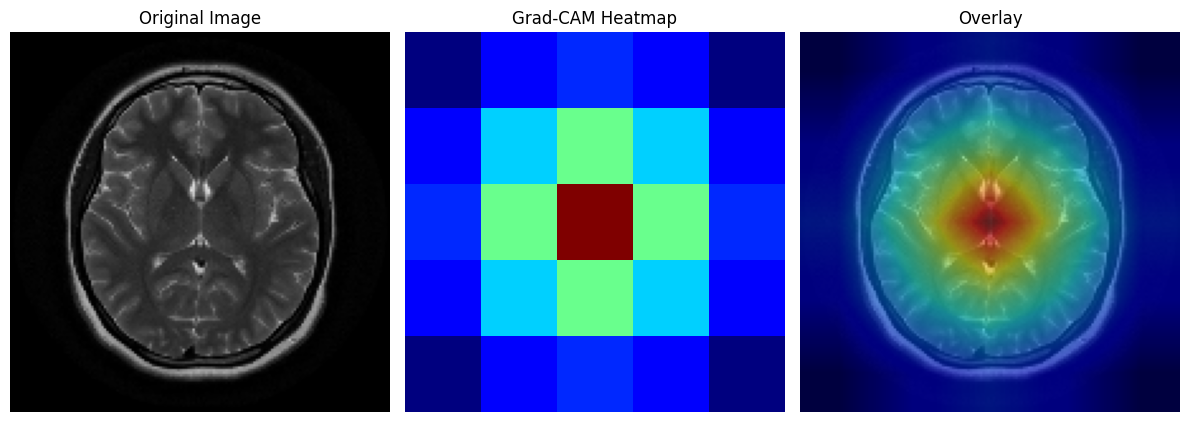


Model prediction: No Tumor (Confidence: 70.35%)


In [7]:
def make_gradcam_heatmap(img_array, model):
    """
    Generate Grad-CAM heatmap - Simplified working version
    """
    # Convert to tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # Find the base MobileNetV2 model
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.applications.MobileNetV2) or \
           (hasattr(layer, '_name') and 'mobilenetv2' in layer._name.lower()) or \
           (isinstance(layer, tf.keras.Model) and len(layer.layers) > 10):
            base_model = layer
            break

    if base_model is None:
        print("Model layers:")
        for i, layer in enumerate(model.layers):
            print(f"{i}: {layer.name} - {type(layer).__name__}")
        raise ValueError("Could not find MobileNetV2 base model")

    print(f"Found base model: {base_model.name}")

    # Find the last convolutional layer in MobileNetV2
    # Common layer names in MobileNetV2: Conv_1, conv_pw_13_relu, out_relu
    possible_layer_names = ['Conv_1', 'conv_pw_13_relu', 'conv_pw_13', 'out_relu']
    last_conv_layer = None

    for layer_name in possible_layer_names:
        try:
            last_conv_layer = base_model.get_layer(layer_name)
            print(f"Using convolutional layer: {layer_name}")
            break
        except ValueError:
            continue

    if last_conv_layer is None:
        # If we can't find by name, find the last Conv2D layer
        for layer in reversed(base_model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer = layer
                print(f"Using last Conv2D layer: {layer.name}")
                break

    if last_conv_layer is None:
        raise ValueError("No convolutional layer found in base model")

    # Create a model that outputs the last conv layer activations
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.outputs]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        # Get the predicted class (or use index 0 for binary classification)
        loss = predictions[0][0]  # For binary classification, take first output

    # Get gradients of loss with respect to conv_outputs
    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        print("Gradients are None. Trying alternative approach...")
        return make_gradcam_alternative(img_array, model, last_conv_layer)

    # Calculate importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv outputs by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) > 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()


def make_gradcam_alternative(img_array, model, target_layer):
    """
    Alternative Grad-CAM implementation
    """
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # Get the base model
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and len(layer.layers) > 10:
            base_model = layer
            break

    # Create intermediate model to get conv features
    feature_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=target_layer.output
    )

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)

        # Get conv features
        conv_features = feature_extractor(img_tensor)

        # Get final predictions
        predictions = model(img_tensor)
        loss = predictions[0][0]

    # Compute gradients
    grads = tape.gradient(loss, conv_features)

    if grads is None:
        print("Still getting None gradients. Using final fallback...")
        return create_dummy_heatmap()

    # Rest of Grad-CAM computation
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_features = conv_features[0]
    heatmap = conv_features @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()


def create_dummy_heatmap():
    """
    Create a dummy heatmap when Grad-CAM fails
    """
    print("Creating dummy heatmap due to gradient issues")
    # Create a simple center-focused heatmap
    size = 5  # Approximate size after conv layers
    heatmap = np.zeros((size, size))
    center = size // 2
    for i in range(size):
        for j in range(size):
            distance = np.sqrt((i - center)**2 + (j - center)**2)
            heatmap[i, j] = np.exp(-distance / 2)

    return heatmap / np.max(heatmap)


# Load and preprocess image
img_path = val_gen.filepaths[0]
print(f"Processing image: {img_path}")

img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Could not load image from {img_path}")

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_array = np.expand_dims(img_resized.astype("float32") / 255.0, axis=0)

print(f"Image shape: {img_array.shape}")
print(f"Model input shape: {tl_model.input_shape}")

# Generate Grad-CAM
try:
    heatmap = make_gradcam_heatmap(img_array, tl_model)
    print(f"Generated heatmap shape: {heatmap.shape}")
except Exception as e:
    print(f"Grad-CAM failed with error: {e}")
    print("Using dummy heatmap...")
    heatmap = create_dummy_heatmap()

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.imshow(cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)), cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

# Also show the model's prediction
prediction = tl_model.predict(img_array, verbose=0)
predicted_class = "Tumor" if prediction[0][0] > 0.5 else "No Tumor"
confidence = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]
print(f"\nModel prediction: {predicted_class} (Confidence: {confidence:.2%})")

In [8]:
tl_model.save("tumor_model_mobilenet.h5")
from google.colab import files
files.download("tumor_model_mobilenet.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>